In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [3]:
outliers1 = df['median_house_value'] == df['median_house_value'].max()
outliers2 = df['housing_median_age'] == df['housing_median_age'].max()
outliers = outliers1 | outliers2

df = df.loc[~outliers, :].copy()
print(df.shape)
df.head(3)

(18572, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


In [4]:
X = df.drop('median_house_value', axis='columns')
y = df['median_house_value']

In [5]:
X['income_cat'] = pd.cut(
    X['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
    )

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=X['income_cat'],
    test_size=0.2
    )

X_train.shape, X_test.shape

((14857, 10), (3715, 10))

In [7]:
X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10):
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(self.n_clusters)
        self.kmeans_.fit(X)
        return self  

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=1).round(3)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_cols = ['ocean_proximity']
log_cols = [
    'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'
    ]

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
log_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')),
    ('scl', StandardScaler())
])

def ratio_func(arr_2d):
    return arr_2d[:, [0]] / arr_2d[:, [1]]
def ratio_feature_names(*args, **kwargs):
    return ['ratio']

rat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('newcol', FunctionTransformer(ratio_func, feature_names_out=ratio_feature_names)),
    ('scl', StandardScaler())
])
cluster_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('cluster', ClusterSimilarity(n_clusters=10))
])
num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler())
])

preprocessing = ColumnTransformer(
    transformers=[
        ('CAT', cat_pipeline, cat_cols),
        ('LOG', log_pipeline, log_cols),
        ('RAT_b/r', rat_pipeline, ['total_bedrooms', 'total_rooms']),
        ('RAT_r/h', rat_pipeline, ['total_rooms', 'households']),
        ('RAT_p/h', rat_pipeline, ['population', 'households']),
        ("GEO", cluster_pipeline, ["latitude", "longitude"]),
    ], remainder=num_pipeline
)

X_train_arr = preprocessing.fit_transform(X_train)
X_train_prepared = pd.DataFrame(X_train_arr, columns=preprocessing.get_feature_names_out())

X_test_arr = preprocessing.fit_transform(X_test)
X_test_prepared = pd.DataFrame(X_test_arr, columns=preprocessing.get_feature_names_out())

X_train_prepared

,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_ISLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,RAT_b/r__ratio,RAT_r/h__ratio,RAT_p/h__ratio,GEO__Cluster 0 similarity,GEO__Cluster 1 similarity,GEO__Cluster 2 similarity,GEO__Cluster 3 similarity,GEO__Cluster 4 similarity,GEO__Cluster 5 similarity,GEO__Cluster 6 similarity,GEO__Cluster 7 similarity,GEO__Cluster 8 similarity,GEO__Cluster 9 similarity,remainder__housing_median_age
0,0.0,1.0,0.0,0.0,0.0,-1.334834,-1.789916,-1.441901,-1.664346,0.908202,-0.968689,0.415067,0.017375,0.000,0.988,0.000,0.000,0.049,0.030,0.000,0.000,0.000,0.097,1.485546
1,0.0,1.0,0.0,0.0,0.0,-3.140742,-3.239369,-2.873927,-3.214448,0.560702,-0.110979,-0.090480,0.041740,0.060,0.000,0.000,0.035,0.000,0.000,0.003,0.569,0.093,0.000,1.485546
2,1.0,0.0,0.0,0.0,0.0,-1.006812,-0.467376,0.295516,-0.655993,-0.822071,1.622641,-0.613699,0.215167,0.000,0.974,0.000,0.000,0.069,0.016,0.000,0.000,0.000,0.089,-0.177516
3,1.0,0.0,0.0,0.0,0.0,0.107460,0.260843,0.115532,0.329407,-0.006041,0.276027,-0.412677,-0.055363,0.000,0.991,0.000,0.000,0.053,0.027,0.000,0.000,0.000,0.094,0.610250
4,0.0,1.0,0.0,0.0,0.0,0.797933,1.218478,0.541743,1.030765,-0.633695,0.986664,-0.400544,-0.091558,0.000,0.858,0.000,0.000,0.014,0.096,0.000,0.000,0.000,0.166,-0.877752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14852,0.0,1.0,0.0,0.0,0.0,-0.120240,-0.128867,-0.319316,-0.160197,-0.576192,-0.116739,-0.039736,-0.047884,0.435,0.000,0.007,0.450,0.000,0.000,0.835,0.157,0.000,0.000,-0.615164
14853,1.0,0.0,0.0,0.0,0.0,-0.414444,-0.681090,-0.638655,-0.661520,0.958545,-0.665586,0.302817,-0.018695,0.051,0.000,0.000,0.164,0.000,0.000,0.011,0.881,0.010,0.000,0.522721
14854,1.0,0.0,0.0,0.0,0.0,0.316145,-0.392815,0.108997,-0.187492,2.234857,-1.471850,0.868016,0.035702,0.000,0.770,0.000,0.000,0.006,0.117,0.000,0.000,0.000,0.399,-1.402930
14855,1.0,0.0,0.0,0.0,0.0,-0.008099,0.584671,0.675215,0.481012,-0.681793,1.684187,-0.739242,0.015942,0.000,0.057,0.009,0.000,0.796,0.000,0.000,0.000,0.000,0.000,-0.352575


In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

full_pipeline = Pipeline([
    ('cleaning', preprocessing),
    ('model', KNeighborsRegressor(n_neighbors=10))
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_pred

array([275650., 156530.,  54310., ...,  81330., 124830., 258460.],
      shape=(3715,))

In [25]:
y_test[:5]

7297     193800.0
14799    117600.0
18923     54100.0
14256    139800.0
462      127400.0
Name: median_house_value, dtype: float64

In [27]:
# np.abs(y_test - y_pred).mean() # mae
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

36413.92721399732

In [30]:
np.mean((y_test - y_pred)**2) #mse
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)

2779427174.2955794

In [31]:
# (np.mean((y_test - y_pred)**2))**(1/2) #rmse
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, y_pred)

52720.27289663417

In [ ]:
# np.mean(np.abs(y_test - y_pred) / y_test) # mape
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test, y_pred)

np.float64(0.20578013074061713)

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

In [38]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6922727378543387

0.20578013074061713

In [39]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [40]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [43]:
X[0].shape

(784,)

In [44]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [45]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [53]:
arr[:10, :10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156]])

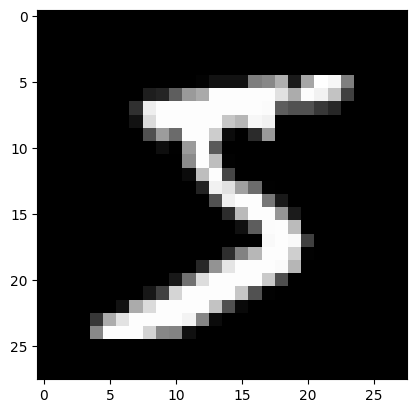

In [51]:
arr = X[0].reshape(28,28)
plt.imshow(arr, cmap='gray')
plt.show()

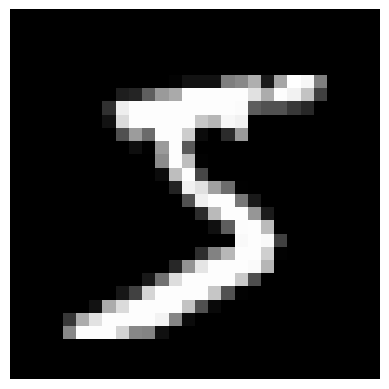

In [54]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)

plt.show()

In [55]:
y[0]

'5'

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
X_train.shape, X_test.shape


((35000, 784), (35000, 784))

## Classification Metrics

In [57]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)
y_pred

c:\Users\user\miniconda3\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['3', '6', '4', ..., '2', '6', '7'], shape=(35000,), dtype=object)

In [58]:
y_test

array(['3', '6', '4', ..., '2', '6', '7'], shape=(35000,), dtype=object)

In [ ]:
# (y_pred == y_test).sum() / y_test.shape[0]
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9161142857142857

In [69]:
lr_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [84]:
3373 / 3502

0.9631639063392348

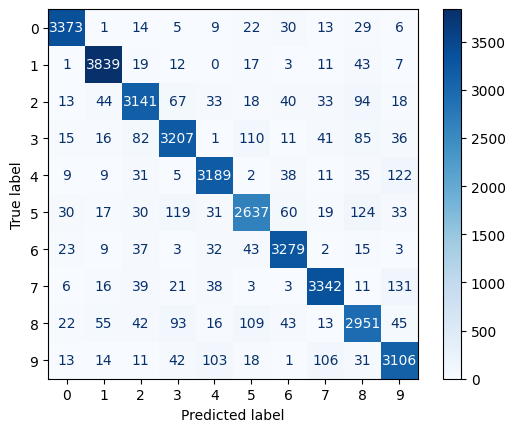

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=lr_clf.classes_)
disp.plot(cmap='Blues')
plt.show()

In [75]:
cm.sum(axis=1)

array([3502, 3952, 3501, 3604, 3451, 3100, 3446, 3610, 3389, 3445])

In [79]:
cm.sum(axis=0)

array([3505, 4020, 3446, 3574, 3452, 2979, 3508, 3591, 3418, 3507])

In [83]:
3502 * 0.96

3361.92

In [85]:
3604 * 0.89

3207.56

In [82]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3502
           1       0.95      0.97      0.96      3952
           2       0.91      0.90      0.90      3501
           3       0.90      0.89      0.89      3604
           4       0.92      0.92      0.92      3451
           5       0.89      0.85      0.87      3100
           6       0.93      0.95      0.94      3446
           7       0.93      0.93      0.93      3610
           8       0.86      0.87      0.87      3389
           9       0.89      0.90      0.89      3445

    accuracy                           0.92     35000
   macro avg       0.91      0.91      0.91     35000
weighted avg       0.92      0.92      0.92     35000

